# Regresión Lineal
Comparación entre ecuación normal y descenso en gradiente.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Datos

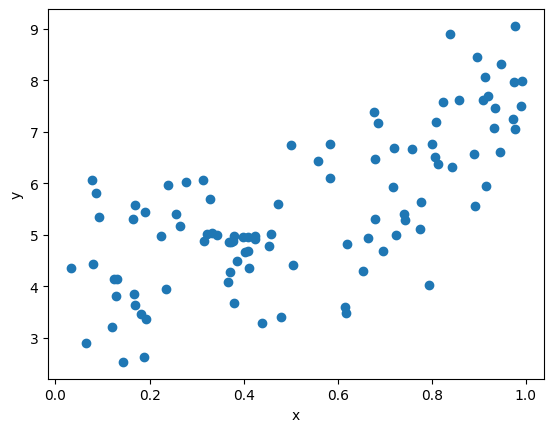

In [22]:
n_samples = 100

x = np.random.rand(n_samples, 1) 
y = 4 + 3 * x[:, 0] + np.random.randn(n_samples)

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Ecuación Normal

La solución analítica exacta:

$$w = (X^TX)^{-1}X^Ty$$

Derivada de poner el gradiente del MSE igual a cero y despejar `w`.
No hay iteraciones — es una sola operación matricial.

In [23]:
X = np.column_stack((np.ones(len(x)), x))

def ecuacion_normal(X, y):
  
    #Definir la función
    XtX = X.T @ X           # (p × p) donde p = n_features
    XtX_inv = np.linalg.inv(XtX)   # inversión — aquí está el costo O(p³)
    Xty = X.T @ y           # (p × 1)
    w = XtX_inv @ Xty
    return w

w = ecuacion_normal(X, y)

b0 = w[0]
b1 = w[1]

print("Intercepto:", b0)
print("Pendiente:", b1)

Intercepto: 3.594794938356902
Pendiente: 3.620355315779199


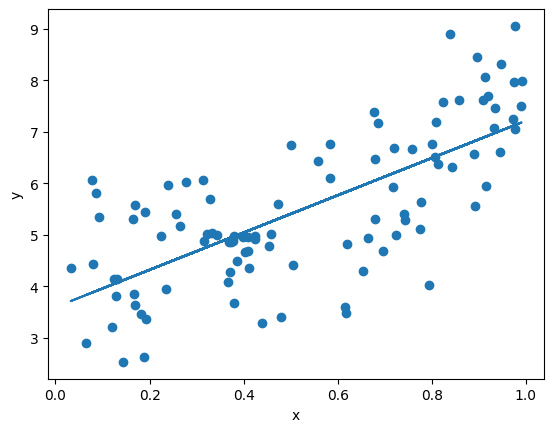

In [24]:
y_pred_normal = X @ w

plt.scatter(x, y)
plt.plot(x, y_pred_normal)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Descenso en Gradiente

La regla de actualización es:

$$w \leftarrow w - \alpha \cdot \nabla MSE(w)$$

Donde el gradiente del MSE es:

$$\nabla MSE(w) = -\frac{2}{n} X^T(y - Xw)$$

Una sola multiplicación matricial por iteración — mucho más barato que invertir.

In [ ]:
def gradiente_descendente(X, y, learning_rate=0.01, n_iter=100, imprimir = True):
    """
    Regresión lineal por Gradiente Descendente (Batch GD).
    
    Actualización: w ← w − α · ∇MSE
    Gradiente:     ∇MSE = −(2/n) · Xᵀ · (y − Xw)
    """
    n, p = X.shape
    w = np.zeros(p)          

    for i in range(n_iter):
        # Predicción actual
         #Completar

        # ∇MSE = −(2/n) · Xᵀ · (y − ŷ)
       #Completar

        # Actualizar pesos
        #Completar

        if imprimir:
            print(f' Iter {i}: w₀={w[0]}  w₁={w[1]}')
        
    return w

w = gradiente_descendente(X, y)

b0 = w[0]
b1 = w[1]


print("Intercepto:", b0)
print("Pendiente:", b1)

 Iter 0: w₀=0.11010580280718457  w₁=0.06409893548439126
 Iter 1: w₀=0.21733297745919122  w₁=0.12657264832978998
 Iter 2: w₀=0.3217562494214391  w₁=0.1874632631253418
 Iter 3: w₀=0.4234484050592825  w₁=0.24681181142339387
 Iter 4: w₀=0.5224803419561259  w₁=0.30465826010283226
 Iter 5: w₀=0.6189211179258248  w₁=0.36104153899641367
 Iter 6: w₀=0.7128379987532549  w₁=0.41599956780119063
 Iter 7: w₀=0.8042965046960516  w₁=0.469569282290633
 Iter 8: w₀=0.8933604557796679  w₁=0.5217866598465665
 Iter 9: w₀=0.9800920159170616  w₁=0.5726867443285779
 Iter 10: w₀=1.0645517358835126  w₁=0.6223036702980803
 Iter 11: w₀=1.1467985951762794  w₁=0.6706706866137825
 Iter 12: w₀=1.2268900427880296  w₁=0.7178201794148762
 Iter 13: w₀=1.3048820369222351  w₁=0.7637836945078279
 Iter 14: w₀=1.380829083677984  w₁=0.808591959172252
 Iter 15: w₀=1.4547842747309523  w₁=0.8522749034009389
 Iter 16: w₀=1.5267993240365862  w₁=0.8948616805887224
 Iter 17: w₀=1.5969246035808669  w₁=0.9363806876844871
 Iter 18: w₀=1.

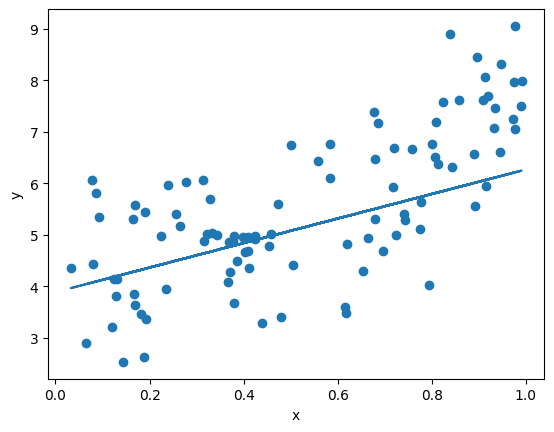

In [26]:
y_pred_gd = b0 + b1 * x

plt.scatter(x, y)
plt.plot(x, y_pred_gd)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Comparación

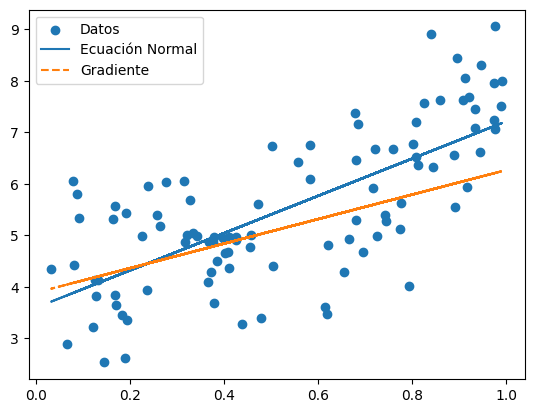

In [27]:
plt.scatter(x, y, label="Datos")
plt.plot(x, y_pred_normal, label="Ecuación Normal")
plt.plot(x, y_pred_gd, linestyle="--", label="Gradiente")

plt.legend()
plt.show()

---
# Resumen

| Concepto | Ecuación Normal | Gradiente Descendente |
|----------|----------------|----------------------|
| **Fórmula** | `w = (XᵀX)⁻¹Xᵀy` | `w ← w − α·∇MSE` |
| **Tipo** | Solución exacta | Aproximación iterativa |
| **Hiperparámetros** | Ninguno | `α`, `n_iter` |
| **Costo** | O(p³) en features | O(n·p) por iteración |
| **n grande** | ❌ Lento | ✅ Eficiente (mini-batch) |
| **p grande** | ❌ Imposible | ✅ Funciona |
| **En sklearn** | `LinearRegression()` | `SGDRegressor()` |

---
### ¿Por qué sklearn es rápido?

`LinearRegression()` usa **SVD** (Descomposición en Valores Singulares)  
en vez de invertir directamente — más estable numéricamente y más eficiente.

Para datasets grandes (millones de filas o features), sklearn recomienda `SGDRegressor`.